# Loading Libraries....

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings, gc
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

import lightgbm as lgb
import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

import xgboost as xgb
from xgboost import XGBClassifier

import catboost as cb
from catboost import CatBoostClassifier

print("All  Libraries Set")

All  Libraries Set


# Loading Training and Testing Datasets

In [2]:
train_data = pd.read_csv("../input/titanic/train.csv")
test = pd.read_csv("../input/titanic/test.csv")

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train_data.shape,test.shape 

((891, 12), (418, 11))

# Handling Missing Values

<AxesSubplot:>

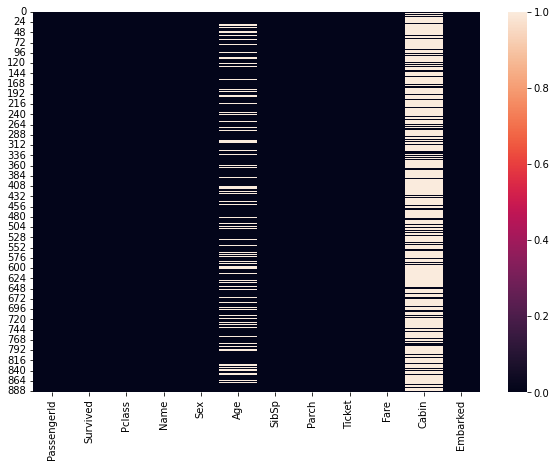

In [4]:
plt.figure(figsize=(10,7))

sns.heatmap(data= train_data.isnull())

<AxesSubplot:>

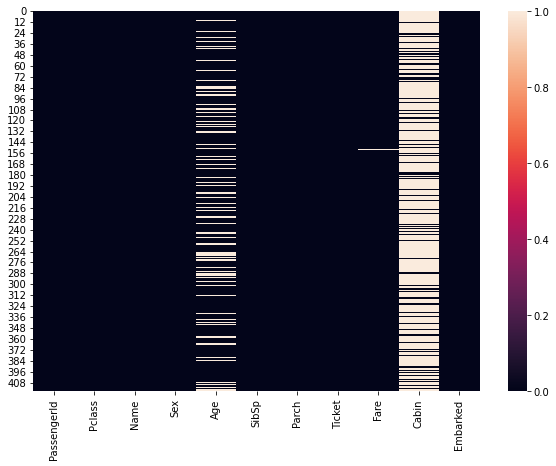

In [5]:
plt.figure(figsize=(10,7))

sns.heatmap(data= test.isnull())

As we can see Age , Fare and Cabin columns have null values so we replace Age and Fare null values with with there mean and Cabin null values with 2nd most occured cabin code.

In [6]:
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
test['Age'] = test['Age'].fillna(test['Age'].mean())

In [7]:
train_data['Fare'] = train_data['Fare'].fillna(train_data['Fare'].mean())
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [8]:
train_data['Cabin'] = train_data['Cabin'].fillna(train_data['Cabin'].value_counts().index[1])
test['Cabin'] = test['Cabin'].fillna(test['Cabin'].value_counts().index[1])

<AxesSubplot:>

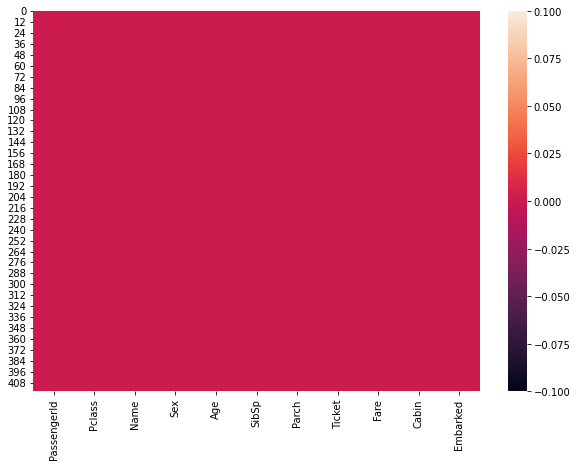

In [9]:
plt.figure(figsize=(10,7))

sns.heatmap(data= test.isnull())

<AxesSubplot:>

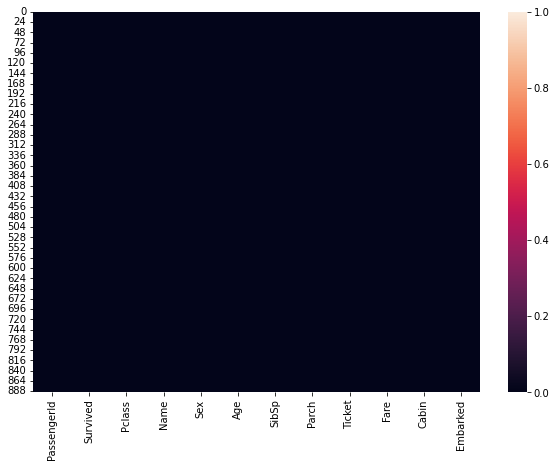

In [10]:
plt.figure(figsize=(10,7))

sns.heatmap(data= train_data.isnull())

# EDA & Feature Engineering

In [11]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,G6,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,G6,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,G6,S


<AxesSubplot:xlabel='Survived', ylabel='count'>

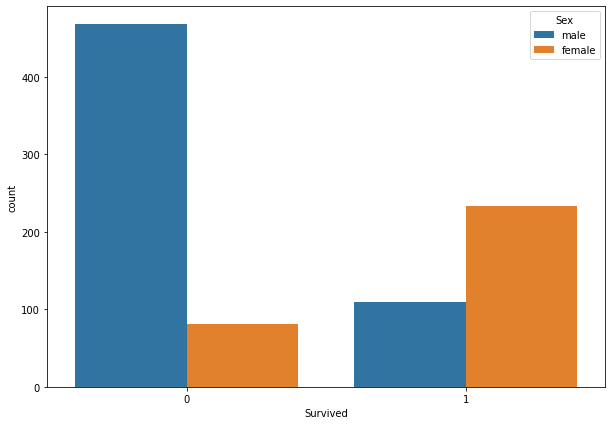

In [12]:
plt.figure(figsize=(10,7))

sns.countplot( x= train_data["Survived"],hue=train_data["Sex"])

<AxesSubplot:xlabel='Family_size', ylabel='Survived'>

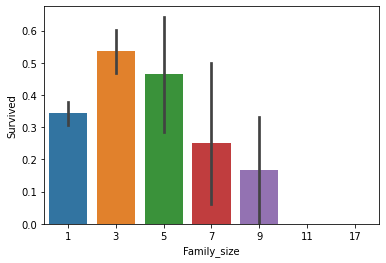

In [13]:
train_data['Family_size'] = train_data['SibSp'] + train_data['SibSp'] + 1
test['Family_size'] = test['SibSp'] + test['SibSp'] + 1

sns.barplot(x="Family_size",y="Survived",data=train_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

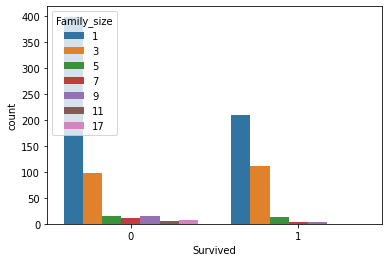

In [14]:
sns.countplot(x='Survived',hue='Family_size',data=train_data)

<AxesSubplot:xlabel='Age_bin', ylabel='Survived'>

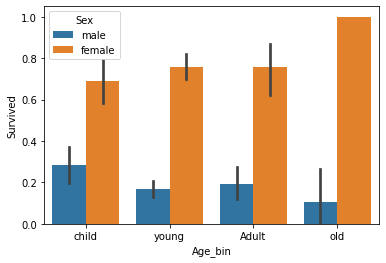

In [15]:
train_data['Age_bin'] = pd.cut(train_data['Age'],4,labels=["child",'young','Adult','old'])
test['Age_bin'] = pd.cut(test['Age'],4,labels=["child",'young','Adult','old'])

sns.barplot(x='Age_bin',y='Survived',hue="Sex",data=train_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

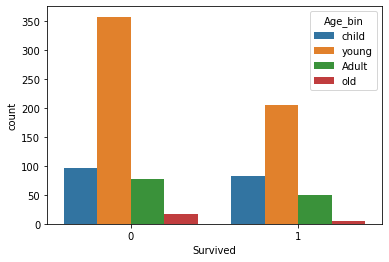

In [16]:
sns.countplot(x='Survived',hue='Age_bin',data=train_data)

<AxesSubplot:xlabel='Fare_bin', ylabel='Survived'>

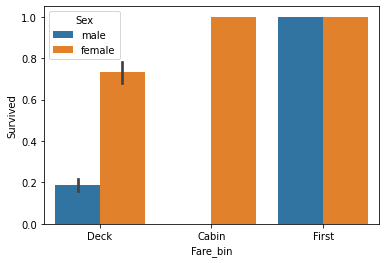

In [17]:
train_data['Fare_bin'] = pd.cut(train_data['Fare'],3,labels=["Deck",'Cabin','First'])
test['Fare_bin'] = pd.cut(test['Fare'],3,labels=["Deck",'Cabin','First'])

sns.barplot(x='Fare_bin',y='Survived',hue="Sex",data=train_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

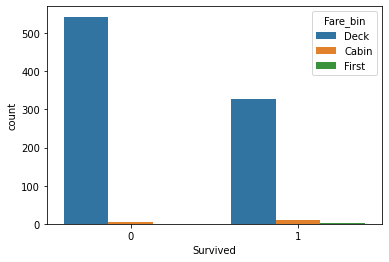

In [18]:
sns.countplot(x='Survived',hue='Fare_bin',data=train_data)

In [19]:
def title(name):
    """This will extract first letters till .(dot)from 
    name column using re module
    """
    title_search = re.search('([A-Za-z]+)\.',name)
    if title_search:
        return title_search.group(1)
    return ""

<AxesSubplot:xlabel='Title', ylabel='Survived'>

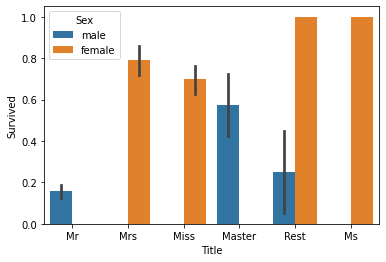

In [20]:
# Exactracting Titiles from Name column and keeping most occured and rest replacing with Rest as  title.
train_data['Title'] = train_data['Name'].apply(title)
test['Title'] = test['Name'].apply(title)

train_data['Title'] = train_data['Title'].replace(['Lady', 'Countess','Capt', 'Col',
 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona','Mme','Mlle'], 'Rest')
test['Title'] = test['Title'].replace(['Lady', 'Countess','Capt', 'Col',
 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona','Mme','Mlle'], 'Rest')
sns.barplot(x='Title',y='Survived',hue="Sex",data=train_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

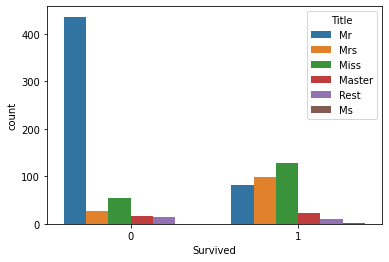

In [21]:
sns.countplot(x='Survived',hue='Title',data=train_data)

In [22]:
def ticket(name):
    """ This will extract first letters from Ticket and replace 
    the with no first letters with bunk class"""
    title_search = re.search('([A-Za-z]+)\.',name)
    if title_search:
        return title_search.group(1)
   
    return "Bunk"

<AxesSubplot:xlabel='Tk', ylabel='Survived'>

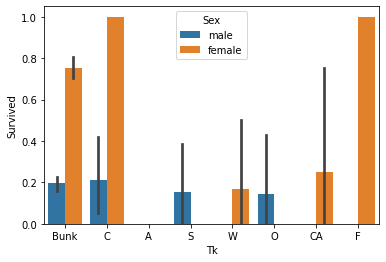

In [23]:
train_data['Tk'] = train_data['Ticket'].apply(ticket)
test['Tk'] = test["Ticket"].apply(ticket)

sns.barplot(x='Tk',y='Survived',hue="Sex",data=train_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

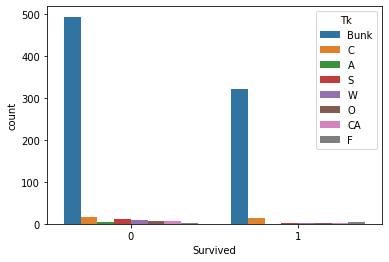

In [24]:
sns.countplot(x="Survived",hue="Tk",data=train_data)

In [25]:
#this is done coz Test data has Ticket class OQ which is not present in Train and its only one case.
# insted of completly dropping column we change it to one which is present in train and test.
#If not replaced it will coz problems  while labelencoding catogorical columns
test["Tk"] =test['Tk'].replace(['OQ'], 'CA')

<AxesSubplot:xlabel='Embarked', ylabel='Survived'>

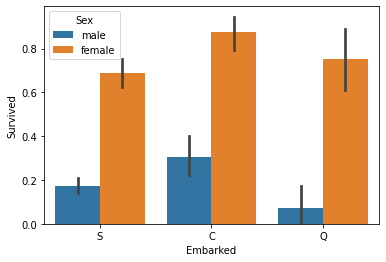

In [26]:
sns.barplot(x='Embarked',y='Survived',hue="Sex",data=train_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

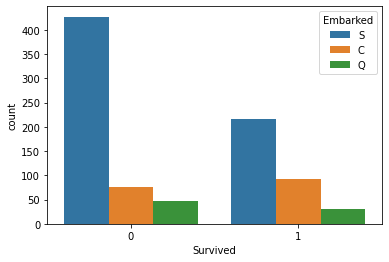

In [27]:
sns.countplot(x="Survived",hue="Embarked",data=train_data)

<AxesSubplot:xlabel='Cabin_code', ylabel='Survived'>

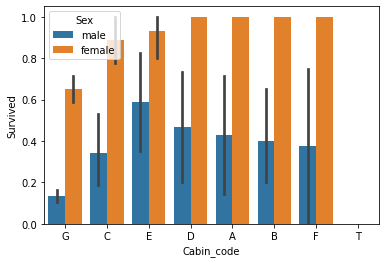

In [28]:
# Here we split Cabin code and just take first letter of it with lambda function
train_data['Cabin_code'] = train_data['Cabin'].apply(lambda x: str(x)[0])
test['Cabin_code'] = test['Cabin'].apply(lambda x: str(x)[0])

sns.barplot(x='Cabin_code',y='Survived',hue="Sex",data=train_data)

<AxesSubplot:xlabel='Survived', ylabel='count'>

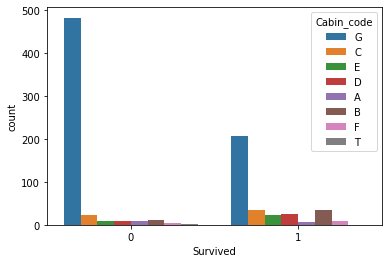

In [29]:
sns.countplot(x="Survived",hue="Cabin_code",data=train_data)

In [30]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_size,Age_bin,Fare_bin,Title,Tk,Cabin_code
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,G6,S,3,young,Deck,Mr,Bunk,G
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,3,young,Deck,Mrs,Bunk,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,G6,S,1,young,Deck,Miss,Bunk,G
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3,young,Deck,Mrs,Bunk,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,G6,S,1,young,Deck,Mr,Bunk,G


In [31]:
# Defining X (features) and y (targets ) to train the data
y = train_data["Survived"]

X= train_data.drop(['PassengerId','Cabin','Age','Fare',"Survived",'Name','Ticket'],axis=1)

test_f = test.drop(['PassengerId','Cabin','Age','Fare','Name','Ticket'],axis=1)

In [32]:
test_f

,Pclass,Sex,SibSp,Parch,Embarked,Family_size,Age_bin,Fare_bin,Title,Tk,Cabin_code
0,3,male,0,0,Q,1,young,Deck,Mr,Bunk,B
1,3,female,1,0,S,3,Adult,Deck,Mrs,Bunk,B
2,2,male,0,0,Q,1,old,Deck,Mr,Bunk,B
3,3,male,0,0,S,1,young,Deck,Mr,Bunk,B
4,3,female,1,1,S,3,young,Deck,Mrs,Bunk,B
...,...,...,...,...,...,...,...,...,...,...,...
413,3,male,0,0,S,1,young,Deck,Mr,A,B
414,1,female,0,0,C,1,Adult,Deck,Rest,Bunk,C
415,3,male,0,0,S,1,Adult,Deck,Mr,O,B
416,3,male,0,0,S,1,young,Deck,Mr,Bunk,B


In [33]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Pclass       891 non-null    int64   
 1   Sex          891 non-null    object  
 2   SibSp        891 non-null    int64   
 3   Parch        891 non-null    int64   
 4   Embarked     889 non-null    object  
 5   Family_size  891 non-null    int64   
 6   Age_bin      891 non-null    category
 7   Fare_bin     891 non-null    category
 8   Title        891 non-null    object  
 9   Tk           891 non-null    object  
 10  Cabin_code   891 non-null    object  
dtypes: category(2), int64(4), object(5)
memory usage: 64.8+ KB


In [34]:
cat_cols = [ col for col in X.columns  if X[col].dtype not in ["int64",'float64']]

num_cols = [col for col in X.columns if X[col].dtype  in ["int64",'float64']]

In [35]:
# Encoding Catagorical data to numerical with Labelencoder 
lab = LabelEncoder()

for col in X[cat_cols]:
    X[col] = lab.fit_transform(X[col])
    test_f[col] = lab.transform(test_f[col])

In [36]:
X.head()

,Pclass,Sex,SibSp,Parch,Embarked,Family_size,Age_bin,Fare_bin,Title,Tk,Cabin_code
0,3,1,1,0,2,3,3,1,2,1,6
1,1,0,1,0,0,3,3,1,3,1,2
2,3,0,0,0,2,1,3,1,1,1,6
3,1,0,1,0,2,3,3,1,3,1,2
4,3,1,0,0,2,1,3,1,2,1,6


In [37]:
test_f.head()

,Pclass,Sex,SibSp,Parch,Embarked,Family_size,Age_bin,Fare_bin,Title,Tk,Cabin_code
0,3,1,0,0,1,1,3,1,2,1,1
1,3,0,1,0,2,3,0,1,3,1,1
2,2,1,0,0,1,1,2,1,2,1,1
3,3,1,0,0,2,1,3,1,2,1,1
4,3,0,1,1,2,3,3,1,3,1,1


# Normalizing Data**

In [38]:
X_numpy = np.array(X,dtype="float16")
y_numpy = np.array(y)
test_numpy = np.array(test_f,dtype='float16')

In [39]:
mean = X_numpy.mean(axis=0)
std = X_numpy.std(axis=0)

X_numpy -=mean
X_numpy/=std

test_numpy-=mean
test_numpy/=std

# Training using Xgboost Classifier 

In [40]:
# Lets split the data to trainig and validation set train on training set and then validate our results with Validation set

X_train_xgbm,X_valid_xgbm,y_train_xgbm,y_valid_xgbm = train_test_split(X_numpy, y_numpy, test_size=0.30,stratify=y_numpy)

In [41]:
xgb_parms ={
    'booster': 'gbtree',
    'lambda': 2.881670618102618e-06,
    'alpha': 1.0193368442278269e-08,
    'subsample': 0.5799377275039355,
    'colsample_bytree': 0.8155726685728971,
    'max_depth': 9,
    'min_child_weight': 6,
    'eta': 7.769322096811235e-06,
    'gamma': 6.069119344385817e-06,
    'grow_policy': 'depthwise',
     'n_estimators':200}

In [42]:
xgbm = XGBClassifier(**xgb_parms)
xgbm.fit(X_train_xgbm, y_train_xgbm,
             early_stopping_rounds=10,
             eval_set=[(X_valid_xgbm, y_valid_xgbm)],
             verbose=0)  
                          

XGBClassifier(alpha=1.0193368442278269e-08, base_score=0.5, booster='gbtree',
              callbacks=None, colsample_bylevel=1, colsample_bynode=1,
              colsample_bytree=0.8155726685728971, early_stopping_rounds=None,
              enable_categorical=False, eta=7.769322096811235e-06,
              eval_metric=None, gamma=6.069119344385817e-06, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', lambda=2.881670618102618e-06,
              learning_rate=7.76932211e-06, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=9, max_leaves=0, min_child_weight=6,
              missing=nan, monotone_constraints='()', n_estimators=200,
              n_jobs=0, num_parallel_tree=1, predictor='auto', ...)

<AxesSubplot:>

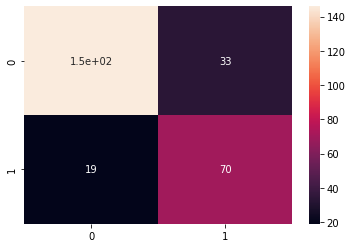

In [43]:
y_pred_valid_xgbm = xgbm.predict(X_valid_xgbm)

cm_xgbm = confusion_matrix(y_pred_valid_xgbm,y_valid_xgbm)
sns.heatmap(data=cm_xgbm,annot=True)

In [44]:
cr_xgbm = classification_report(y_pred_valid_xgbm,y_valid_xgbm)

print(cr_xgbm)

              precision    recall  f1-score   support

           0       0.88      0.82      0.85       179
           1       0.68      0.79      0.73        89

    accuracy                           0.81       268
   macro avg       0.78      0.80      0.79       268
weighted avg       0.82      0.81      0.81       268



# Light GBM

In [45]:
X_train_lgbm,X_valid_lgbm,y_train_lgbm,y_valid_lgbm = train_test_split(X_numpy, y_numpy, test_size=0.30,stratify=y_numpy)

In [46]:
lgbm_parms={
    'n_estimators':150,
    'lambda_l1': 0.00017327448532423561,
    'lambda_l2': 4.612552962137817e-06,
    'num_leaves': 230,
    'feature_fraction': 0.527821945821783,
    'bagging_fraction': 0.5466724425663305,
    'bagging_freq': 2,
    'min_child_samples': 45,
}

In [47]:
lgbm =LGBMClassifier(**lgbm_parms).fit(X_train_lgbm, y_train_lgbm, 
                                       eval_set=[(X_train_lgbm, y_train_lgbm), (X_valid_lgbm, y_valid_lgbm)],
                                       
                                       eval_metric=['auc','binary_logloss'],verbose=0)

[LightGBM] [Warning] lambda_l1 is set=0.00017327448532423561, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.00017327448532423561
[LightGBM] [Warning] feature_fraction is set=0.527821945821783, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.527821945821783
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] lambda_l2 is set=4.612552962137817e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=4.612552962137817e-06
[LightGBM] [Warning] bagging_fraction is set=0.5466724425663305, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5466724425663305


<AxesSubplot:>

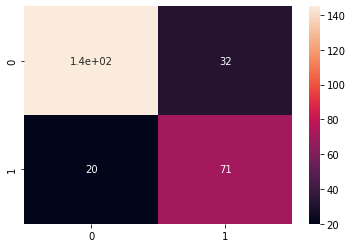

In [48]:
y_pred_valid_lgbm = lgbm.predict(X_valid_lgbm)

cm_lgbm = confusion_matrix(y_pred_valid_lgbm,y_valid_lgbm)
sns.heatmap(data=cm_lgbm,annot=True)

In [49]:
cr_lgbm = classification_report(y_pred_valid_lgbm,y_valid_lgbm)

print(cr_lgbm)

              precision    recall  f1-score   support

           0       0.88      0.82      0.85       177
           1       0.69      0.78      0.73        91

    accuracy                           0.81       268
   macro avg       0.78      0.80      0.79       268
weighted avg       0.81      0.81      0.81       268



In [50]:
X_train_cat,X_valid_cat,y_train_cat,y_valid_cat = train_test_split(X_numpy, y_numpy, test_size=0.30,stratify=y_numpy)

In [51]:
cat_parms={
    'n_estimators':200,
    'objective': 'Logloss',
    'colsample_bylevel': 0.040911949075569096,
    'depth': 5,
    'boosting_type': 'Plain',
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 2.494262586061735}

In [52]:
cbm =CatBoostClassifier(**cat_parms).fit(X_train_cat, y_train_cat, 
                                       eval_set=[(X_train_cat, y_train_cat), (X_valid_cat, y_valid_cat)],
                                      verbose=0,
                                       
                                       )

<AxesSubplot:>

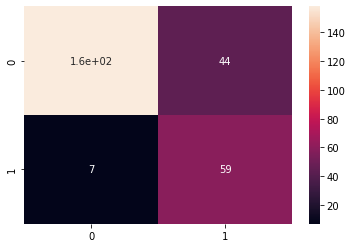

In [53]:
y_pred_valid_cat = cbm.predict(X_valid_cat)

cm_cat = confusion_matrix(y_pred_valid_cat,y_valid_cat)
sns.heatmap(data=cm_cat,annot=True)

In [54]:
cr_cat = classification_report(y_pred_valid_cat,y_valid_cat)

print(cr_cat)

              precision    recall  f1-score   support

           0       0.96      0.78      0.86       202
           1       0.57      0.89      0.70        66

    accuracy                           0.81       268
   macro avg       0.77      0.84      0.78       268
weighted avg       0.86      0.81      0.82       268



# Submission

In [55]:
test_pred_xgbm = xgbm.predict_proba(test_numpy)
preds_xgbm = pd.DataFrame(test_pred_xgbm)
pred_final_xgbm = np.array(preds_xgbm[1])

test_pred_lgbm = lgbm.predict_proba(test_numpy)
preds_lgbm = pd.DataFrame(test_pred_lgbm)
pred_final_lgbm = np.array(preds_lgbm[1])

test_pred_cbm = cbm.predict_proba(test_numpy)
preds_cbm = pd.DataFrame(test_pred_cbm)
pred_final_cbm = np.array(preds_cbm[1])

In [56]:
id=test['PassengerId']
id

0       892
1       893
2       894
3       895
4       896
       ... 
413    1305
414    1306
415    1307
416    1308
417    1309
Name: PassengerId, Length: 418, dtype: int64

In [57]:
d={'XGBM_test':pred_final_xgbm,'LGBM_test':pred_final_lgbm,'CAT_test':pred_final_cbm}
predictions = pd.DataFrame(d,index=id,)

predictions.head()

,XGBM_test,LGBM_test,CAT_test
PassengerId,,,
892,0.499745,0.243616,0.322398
893,0.500080,0.364036,0.585871
894,0.499765,0.211211,0.411353
895,0.499720,0.250012,0.289006
896,0.500062,0.611825,0.627599


In [58]:
predictions['mean']= (predictions['XGBM_test']+predictions['LGBM_test']+predictions['CAT_test'])/3

predictions.head()

,XGBM_test,LGBM_test,CAT_test,mean
PassengerId,,,,
892,0.499745,0.243616,0.322398,0.355253
893,0.500080,0.364036,0.585871,0.483329
894,0.499765,0.211211,0.411353,0.374110
895,0.499720,0.250012,0.289006,0.346246
896,0.500062,0.611825,0.627599,0.579828


In [59]:
submission = pd.read_csv("../input/titanic/gender_submission.csv")

submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [60]:
preds =predictions['mean'].values.round().astype('int16')
preds

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,

In [61]:
submission['Survived'] = preds

submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [62]:
submission.to_csv("submission.csv",index=False)